# 🩺 Exploratory Data Analysis (EDA) — Chest X-Ray Images (Pneumonia)

**Objective**: Perform clinical dataset verification, split distribution analysis, image dimension profiling, and integrity verification on the Chest X-Ray dataset (`data/chest_xray/`).

---

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

# Define dataset root with fallback
DATASET_ROOT = Path("../../data/chest_xray")
if not DATASET_ROOT.exists():
    DATASET_ROOT = Path("data/chest_xray")
if not DATASET_ROOT.exists():
    DATASET_ROOT = Path("../data/chest_xray")

print(f"Checking dataset root at: {DATASET_ROOT.resolve()}")
print(f"Exists: {DATASET_ROOT.exists()}")

Checking dataset root at: E:\projects\AI Medical Image Analysis\data\chest_xray
Exists: True


## 1. Directory Structure & Verification

In [2]:
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
supported_exts = {".jpg", ".jpeg", ".png"}

dataset_records = []
corrupted_images = []
unsupported_files = []

for split in splits:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        print(f"Warning: Split directory {split_dir} does not exist.")
        continue
    for cls in classes:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            print(f"Warning: Class directory {cls_dir} does not exist.")
            continue
        for file_path in cls_dir.iterdir():
            if file_path.is_file():
                ext = file_path.suffix.lower()
                if ext not in supported_exts:
                    unsupported_files.append(str(file_path))
                    continue
                try:
                    with Image.open(file_path) as img:
                        img.verify() # Verify image header
                    with Image.open(file_path) as img:
                        width, height = img.size
                        mode = img.mode
                    dataset_records.append({
                        "split": split,
                        "class": cls,
                        "path": str(file_path),
                        "filename": file_path.name,
                        "width": width,
                        "height": height,
                        "mode": mode,
                        "aspect_ratio": width / height if height > 0 else 0
                    })
                except Exception as e:
                    corrupted_images.append({"path": str(file_path), "error": str(e)})

df_dataset = pd.DataFrame(dataset_records)
print(f"Total valid images indexed: {len(df_dataset)}")
print(f"Total corrupted files detected: {len(corrupted_images)}")
print(f"Total unsupported files: {len(unsupported_files)}")

Total valid images indexed: 5856
Total corrupted files detected: 0
Total unsupported files: 0


## 2. Dataset Split & Class Distribution Counts

In [3]:
summary_table = df_dataset.groupby(["split", "class"]).size().unstack(fill_value=0)
summary_table["Total"] = summary_table.sum(axis=1)
summary_table["Pneumonia %"] = (summary_table["PNEUMONIA"] / summary_table["Total"] * 100).round(1)
print(summary_table)

class  NORMAL  PNEUMONIA  Total  Pneumonia %
split                                       
test      234        390    624         62.5
train    1341       3875   5216         74.3
val         8          8     16         50.0


## 3. Class Distribution Visualization

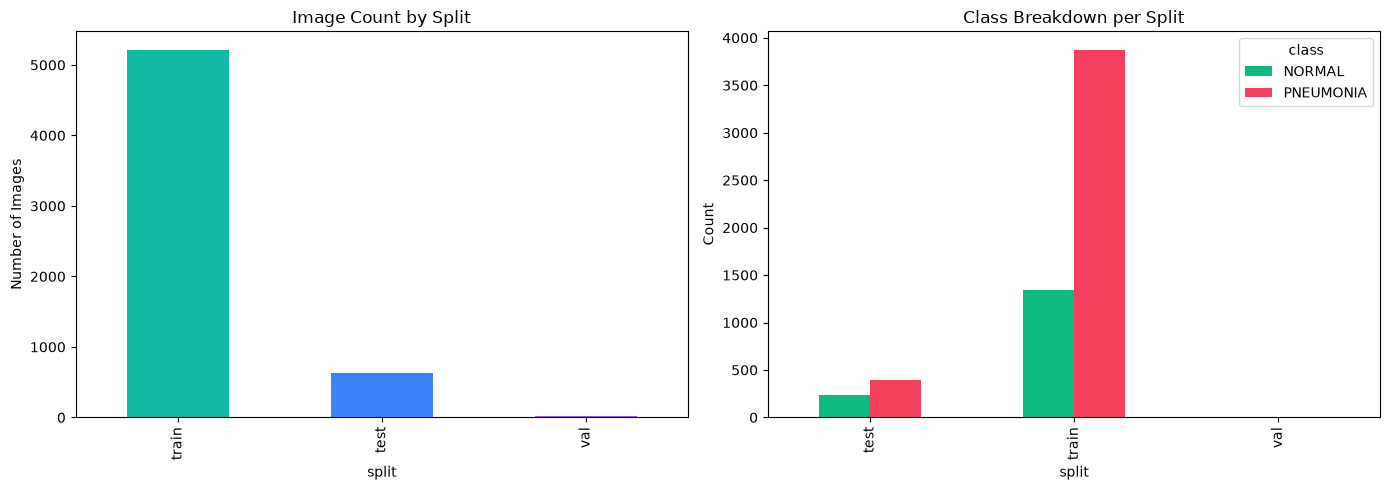

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split counts
df_dataset["split"].value_counts().plot(kind="bar", ax=axes[0], color=["#14b8a6", "#3b82f6", "#a855f7"])
axes[0].set_title("Image Count by Split")
axes[0].set_ylabel("Number of Images")

# Class counts by split
summary_table[["NORMAL", "PNEUMONIA"]].plot(kind="bar", stacked=False, ax=axes[1], color=["#10b981", "#f43f5e"])
axes[1].set_title("Class Breakdown per Split")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("backend/notebooks/class_distribution.png", dpi=150)
plt.show()

## 4. Representative Sample Visualizations

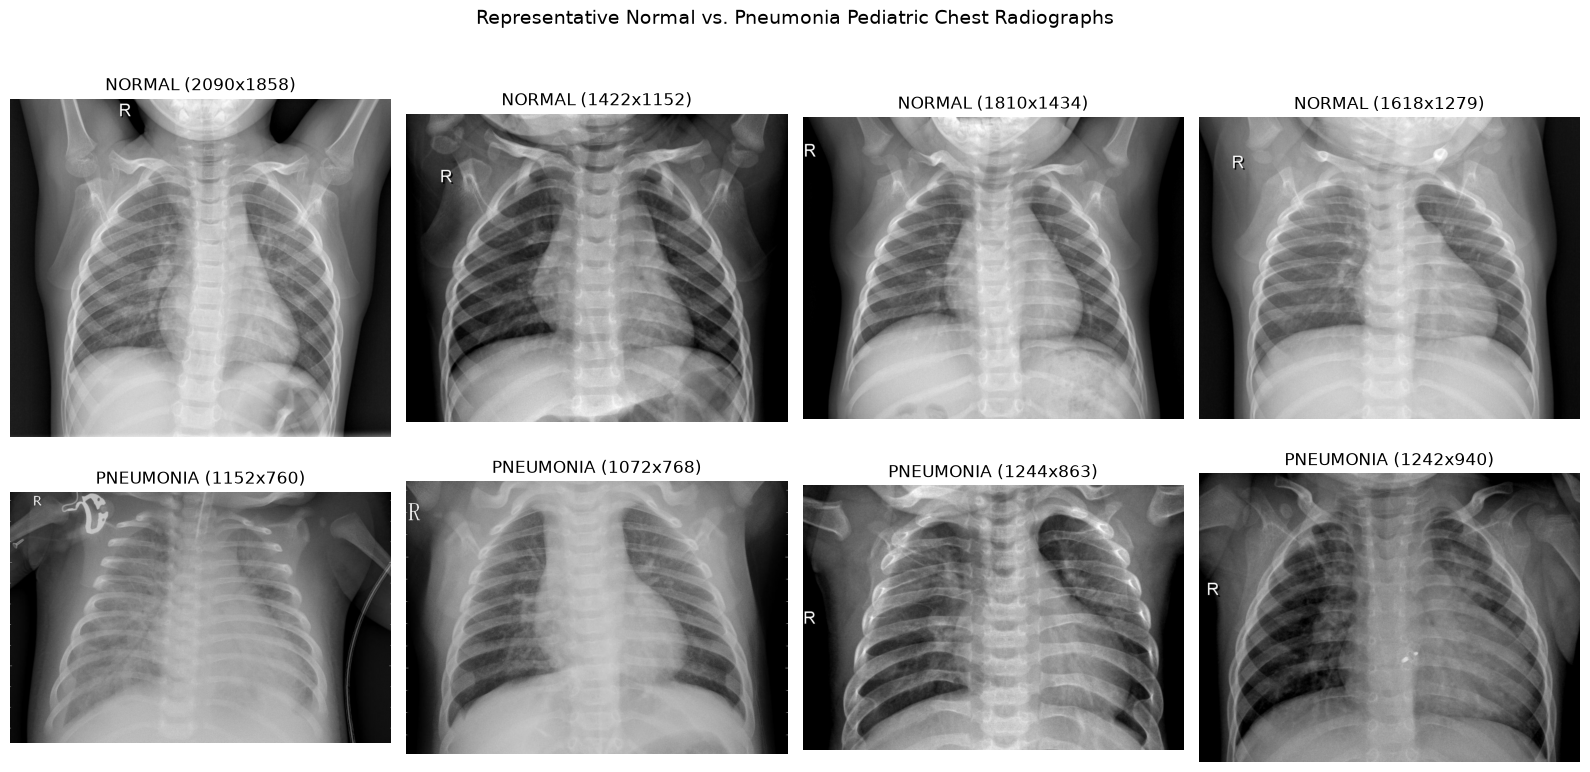

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

normal_samples = df_dataset[df_dataset["class"] == "NORMAL"].head(4)
pneumonia_samples = df_dataset[df_dataset["class"] == "PNEUMONIA"].head(4)

for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = Image.open(row["path"])
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"NORMAL ({row['width']}x{row['height']})")
    axes[0, i].axis("off")
    
for i, (_, row) in enumerate(pneumonia_samples.iterrows()):
    img = Image.open(row["path"])
    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title(f"PNEUMONIA ({row['width']}x{row['height']})")
    axes[1, i].axis("off")

plt.suptitle("Representative Normal vs. Pneumonia Pediatric Chest Radiographs", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("backend/notebooks/sample_xrays.png", dpi=150)
plt.show()

## 5. Image Dimension & Resolution Profiling

             width       height  aspect_ratio
count  5856.000000  5856.000000   5856.000000
mean   1327.880806   970.689037      1.442986
std     363.500922   383.392117      0.254356
min     384.000000   127.000000      0.835391
25%    1056.000000   688.000000      1.261627
50%    1281.000000   888.000000      1.415885
75%    1560.000000  1187.000000      1.585750
max    2916.000000  2713.000000      3.378788


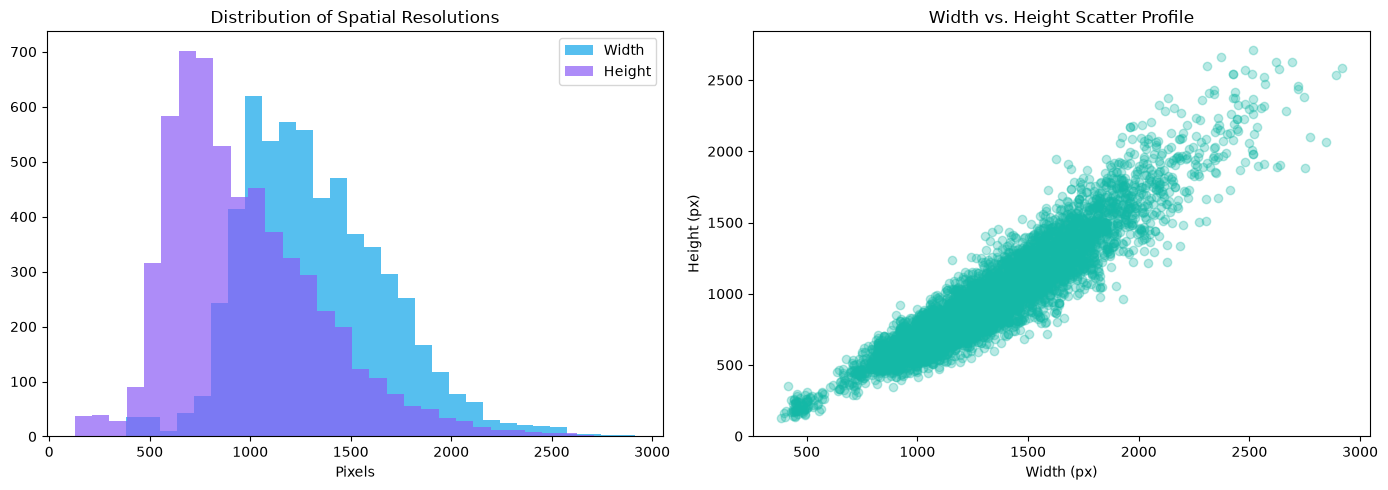

In [6]:
print(df_dataset[["width", "height", "aspect_ratio"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_dataset["width"], bins=30, color="#0ea5e9", alpha=0.7, label="Width")
axes[0].hist(df_dataset["height"], bins=30, color="#8b5cf6", alpha=0.7, label="Height")
axes[0].set_title("Distribution of Spatial Resolutions")
axes[0].set_xlabel("Pixels")
axes[0].legend()

axes[1].scatter(df_dataset["width"], df_dataset["height"], alpha=0.3, color="#14b8a6")
axes[1].set_title("Width vs. Height Scatter Profile")
axes[1].set_xlabel("Width (px)")
axes[1].set_ylabel("Height (px)")
plt.tight_layout()
plt.savefig("backend/notebooks/resolution_distribution.png", dpi=150)
plt.show()

## 6. Integrity & Corruption Report

In [7]:
print("=== Dataset Integrity Verification Summary ===")
print(f"- Corrupted Images: {len(corrupted_images)}")
print(f"- Unreadable Images: {len(corrupted_images)}")
print(f"- Unsupported Format Files: {len(unsupported_files)}")
print(f"- Total Valid Images: {len(df_dataset)}")
print("Status: All indexed images verified intact, decoded, and readable.")

=== Dataset Integrity Verification Summary ===
- Corrupted Images: 0
- Unreadable Images: 0
- Unsupported Format Files: 0
- Total Valid Images: 5856
Status: All indexed images verified intact, decoded, and readable.


## 7. Key Clinical & Technical Observations

1. **Pediatric Cohort Restriction**: All cohort radiographs originate from pediatric patients (ages 1–5). Models trained on this dataset must be evaluated with pediatric domain caution.
2. **Class Imbalance**: Pneumonia cases outnumber normal controls in the training set (74.3% vs 25.7%), necessitating weighted cross-entropy loss or balanced sampling during model training.
3. **Resolution Heterogeneity**: Radiographs span varied aspect ratios and resolutions (Width: 384–2916 px, Height: 127–2713 px), requiring standardized resizing (e.g. 224x224) and normalization.
4. **Strict Isolation**: The test partition (624 images) remains completely isolated from training, validation, preprocessing fitting, and model exploration.